# 14 — Cross-Source Integration & Pre-Load Compatibility Assessment

**Authors:** Gustavo Fuentes (`Audileleach`, Lead Analyst) & Jose Pech (`joseeangel0`, Support & DW Lead)  
**Project:** Mexico City Urban Intelligence (Phase 1 — Cross-Source Evidence)  
**Scope & Contract Reference:** `docs/team/TEAM_PLAN.md` §3.1, §3.5, and §4.6; `data/raw/manifest.json`  

## Purpose and Analytical Scope

While individual profiling notebooks (`10_geographic_assessment.ipynb`, `11_profile_census.ipynb`, `12_profile_denue.ipynb`, and `13_profile_crime.ipynb`) evaluate isolated datasets, this notebook provides the **cross-source integration evidence** required by Phase 1 before ETL ingestion. Specifically, it establishes:

1. **Input Provenance Preflight:** Verifies cryptographically pinned SHA-256 digests across all source archives and extracted members before ingestion, ensuring byte-level integrity and reproducibility.
2. **Geographic Key & Polygon Compatibility:** Validates zero-padded 13-character `CVEGEO` keys between Census 2020 urban aggregates and cartographic polygons (`09a.shp`), quantifying raw mixed grain, strict suppression handling, and the two orphan census keys excluded from the spatial frame.
3. **DENUE Geographic Code vs. Spatial Join Concordance:** Compares reported administrative identifiers (`cve_ent` + `cve_mun` + `cve_loc` + `ageb`) against point-in-polygon spatial assignment using the shared `assign_ageb` helper in `EPSG:6372`, presenting a complete mutually exclusive partition and empirical discrepancy analysis.
4. **Cross-Source Temporal Coverage Mismatch:** Distinguishes the decennial stock measurement of Census 2020 (reference date 15 March 2020), the directory snapshot nature and registration waves (`fecha_alta`) of DENUE 05/2026, and the 7-month procedural filing window (`fecha_inicio`, Jan–Jul 2024; 213 observed days) of FGJ crime files. Preserves unobserved Aug–Dec months as missing (`NaN`).
5. **Source-to-Urban-AGEB Summary Funnel Table:** Reconciles raw inputs to retained warehouse entities (2,431 polygons, 9,138,524 residents, 461,231 establishments, and 112,285 crime incidents), establishing the analytical boundaries for Phase 2 ETL and Phase 3 analytics.


Prerequisites, read-only provenance recovery and the issue #26 approval evidence map: [docs/integration_check.md](../docs/integration_check.md). Prepare geography before this Phase 1 check; other report/contract-suite deliverables remain separate tasks.

Review corrections and regression evidence: Valeria Hernandez (`valnix140405`).

In [1]:
from pathlib import Path
import sys
import warnings

# Ensure project root is available on sys.path
ROOT = next((parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "src").is_dir()), Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analysis.integration import (
    build_source_integration_summary_table,
    census_polygon_compatibility,
    crime_temporal_and_grain_check,
    denue_code_compatibility,
    plot_cross_source_temporal_coverage,
    verify_input_provenance,
)
from src.config import CRIME_YEAR, DATA_RAW, OUTPUT_FIGURES
from src.transform.spatial import load_ageb
from src.transform.denue import parse_alta_date, read_denue

warnings.filterwarnings("ignore", category=UserWarning)

# Preflight: Verify input file provenance and cryptographic digests
print("=== Input Provenance Preflight Check ===")
verified_provenance = verify_input_provenance()
for ds_name, sha in verified_provenance.items():
    print(f"  [OK] {ds_name}: SHA-256 {sha[:16]}... verified")

print("\nProject root resolved successfully.")
print(f"Raw data directory configured: {DATA_RAW.name}")

print("Consumed extracted members and processed geography match the approved sources.")


=== Input Provenance Preflight Check ===


  [OK] census_ageb_2020_09: SHA-256 1f5f123b8e9a5099... verified
  [OK] denue_09: SHA-256 ae608f30118f6313... verified
  [OK] marco_geo_2020_09: SHA-256 685b912f5458138a... verified
  [OK] crime_fgj_2024: SHA-256 2ac3f17189a61ab7... verified

Project root resolved successfully.
Raw data directory configured: raw
Consumed extracted members and processed geography match the approved sources.


## 1. Census-to-Polygon CVEGEO Compatibility

In Mexico's national statistical system, the geostatistical identifier `CVEGEO` encodes hierarchical administration:  
$$\text{CVEGEO} = \underbrace{\text{ENTIDAD}}_{2\text{ digits}} + \underbrace{\text{MUN}}_{3\text{ digits}} + \underbrace{\text{LOC}}_{4\text{ digits}} + \underbrace{\text{AGEB}}_{4\text{ chars}} = 13\text{ characters}$$

In the raw Censo de Población y Vivienda 2020 (`conjunto_de_datos_ageb_urbana_09_cpv2020.csv`), rows mix multiple nested aggregates (state total, alcaldía totals, locality totals, AGEB totals, and block totals). To isolate genuine AGEB aggregates, we select rows where `MZA == '000'` and `AGEB != '0000'`.

We evaluate this key set against the official 2020 cartographic layer (`09a.shp` / `ageb.parquet`) using strict numerical parsing that preserves statistical suppression symbols (`*`, `N/D`) as missing without silent coercion to zero.


Matched `POBTOT` must be available under the warehouse contract. Orphan sums preserve wholly unavailable population and disclose observed/missing coverage; partial sums are known subtotals.

In [2]:
# Execute census compatibility evaluation
census_comp = census_polygon_compatibility()

print("=== Census 2020 to Cartographic Polygon Compatibility ===")
print(f"Total raw census rows (mixed grain):     {census_comp['raw_census_rows']:,}")
print(f"Selected urban AGEB total rows:          {census_comp['total_census_agebs']:,}")
print(f"Matched urban AGEBs in cartography:      {census_comp['matched_agebs']:,}")
print(f"Orphan census AGEBs (no polygon):        {census_comp['orphan_count']:,}")
print(f"Total population in matched AGEBs:       {census_comp['matched_population']:,}")
orphan_population_label = f"{census_comp['orphan_population']:,}" if pd.notna(census_comp['orphan_population']) else "unavailable"
print(f"Orphan population (known subtotal):      {orphan_population_label}")
print(f"Matched population observed/missing:     {census_comp['matched_population_observed_count']} / {census_comp['matched_population_missing_count']}")
print(f"Orphan population observed/missing:      {census_comp['orphan_population_observed_count']} / {census_comp['orphan_population_missing_count']}")
print(f"Orphan population coverage complete:     {census_comp['orphan_population_complete']}")
print(f"Matched keys exactly equal polygon set:  {census_comp['keys_match_polygons']}")

print("\nOrphan Census AGEB Details:")
display(census_comp["orphan_summary"])

# Contract assertions against TEAM_PLAN §3.5 ground truth
assert census_comp["raw_census_rows"] == 68_941, f"Expected 68,941 raw census rows, got {census_comp['raw_census_rows']}"
assert census_comp["total_census_agebs"] == 2_433, f"Expected 2,433 AGEBs, got {census_comp['total_census_agebs']}"
assert census_comp["matched_agebs"] == 2_431, f"Expected 2,431 matched AGEBs, got {census_comp['matched_agebs']}"
assert census_comp["matched_population"] == 9_138_524, f"Expected 9,138,524 matched residents, got {census_comp['matched_population']}"
assert census_comp["orphan_count"] == 2, f"Expected 2 orphan AGEBs, got {census_comp['orphan_count']}"
assert census_comp["orphan_keys"] == ["0901101101107", "0901201351227"], f"Unexpected orphan keys: {census_comp['orphan_keys']}"
assert census_comp["orphan_population"] == 7_108, f"Expected 7,108 orphan residents, got {census_comp['orphan_population']}"
assert census_comp["keys_match_polygons"] is True, "Matched census keys do not equal cartographic polygon keys!"
assert len(census_comp["polygon_orphans"]) == 0, f"Found cartographic polygons without census data: {census_comp['polygon_orphans']}"
print("\n[OK] Census-polygon compatibility successfully reproduces TEAM_PLAN §3.5 reference values.")


=== Census 2020 to Cartographic Polygon Compatibility ===
Total raw census rows (mixed grain):     68,941
Selected urban AGEB total rows:          2,433
Matched urban AGEBs in cartography:      2,431
Orphan census AGEBs (no polygon):        2
Total population in matched AGEBs:       9,138,524
Orphan population (known subtotal):      7,108
Matched population observed/missing:     2431 / 0
Orphan population observed/missing:      2 / 0
Orphan population coverage complete:     True
Matched keys exactly equal polygon set:  True

Orphan Census AGEB Details:


,cvegeo,mun_name,cve_mun,pop_total
0,0901101101107,Tláhuac,011,3050
1,0901201351227,Tlalpan,012,4058



[OK] Census-polygon compatibility successfully reproduces TEAM_PLAN §3.5 reference values.


### Methodological Note on Census Exclusions and Reference Timing

- **Census Reference Date vs. Enumeration Window:** The official demographic reference date for the 2020 Census is **15 March 2020**, while on-the-ground census enumeration took place from **March 2 to March 27, 2020**.
- **Cartographic Discrepancies:** Two urban AGEBs present in the Census 2020 tables have no corresponding polygon geometry in the INEGI Marco Geoestadístico 2020 (`09a.shp`):
  - **`0901101101107`** (Alcaldía Tláhuac, `cve_mun='011'`): 3,050 residents
  - **`0901201351227`** (Alcaldía Tlalpan, `cve_mun='012'`): 4,058 residents
  - **Total excluded population:** 7,108 residents (~0.078% of the 9,145,632 urban census residents).

**Why these exclusions matter:**  
1. **Spatial Join Viability:** Because these two units lack boundary polygons, point observations (DENUE establishments and FGJ crime incidents) cannot be spatially linked to them using point-in-polygon predicates (`within`).
2. **Spatial Weights & Autocorrelation:** PySAL contiguity matrices (Queen / KNN) require valid polygon topologies. Non-spatial tabular units would disrupt neighbourhood graphs and spatial lag computations.
3. **Coverage Impact:** Retaining 2,431 AGEBs preserves **99.92%** of urban census residents and **99.22%** of the entire state population (9,209,944). All 2,431 loaded polygons (including 83 outlying units) have complete demographic matching.


## 2. DENUE Reported Geographic Codes vs. Point-in-Polygon Spatial Assignment

The DENUE economic directory publishes nominal administrative codes for each establishment (`cve_ent`, `cve_mun`, `cve_loc`, and `ageb`), which are concatenated into a 13-character `cvegeo_reported`. In parallel, each establishment includes geocoded GPS coordinates (`latitud`, `longitud`).

To prevent boundary artefacts and guarantee physical spatial containment, our pipeline applies a geometric point-in-polygon join using `assign_ageb` with predicate `within` against the EPSG:6372 AGEB polygons. We classify all assigned points into a mutually exclusive partition:
1. **Exact Agreement:** Assigned spatial polygon `CVEGEO` equals nominal `cvegeo_reported`.
2. **Reported-versus-Spatial Discrepancy:** Valid nominal reported code differs from assigned spatial polygon.
3. **Unmatchable Reported Key:** Nominal code has missing components or invalid syntax.


In [3]:
# Execute DENUE code compatibility evaluation
denue_comp = denue_code_compatibility()

print("=== DENUE Reported Code vs. Spatial Join Concordance ===")
print(f"Total raw economic establishments:       {denue_comp['raw_count']:,}")
print(f"Dropped invalid/out-of-study coordinates: {denue_comp['invalid_coords_count']:,}")
print(f"Establishments with valid coordinates:    {denue_comp['valid_coords_count']:,}")
print(f"Retained inside urban AGEB polygons:      {denue_comp['retained_count']:,}")
print(f"Dropped outside urban AGEB polygons:      {denue_comp['outside_count']:,}")
print(f"Reported code matched assigned polygon:   {denue_comp['matched_cvegeo']:,}")
print(f"Reported-versus-spatial discrepancy:      {denue_comp['discrepancy_cvegeo']:,}")
print(f"Unmatchable reported keys:                {denue_comp['unmatchable_cvegeo']:,}")
print(f"Eligible comparison denominator:          {denue_comp['eligible_denominator']:,}")
print(f"Concordance rate on eligible denominator: {denue_comp['agreement_rate']:.4%}")

# Complete partition breakdown table
denue_breakdown = pd.DataFrame([
    {
        "Classification": "Exact Agreement (Reported == Spatial Join)",
        "Count": denue_comp["matched_cvegeo"],
        "Share of Retained (%)": round(denue_comp["matched_cvegeo"] / denue_comp["retained_count"] * 100, 2),
    },
    {
        "Classification": "Reported-versus-Spatial Discrepancy (Valid Key != Spatial Join)",
        "Count": denue_comp["discrepancy_cvegeo"],
        "Share of Retained (%)": round(denue_comp["discrepancy_cvegeo"] / denue_comp["retained_count"] * 100, 2),
    },
    {
        "Classification": "Unmatchable Reported Key (Missing / Malformed Syntax)",
        "Count": denue_comp["unmatchable_cvegeo"],
        "Share of Retained (%)": round(denue_comp["unmatchable_cvegeo"] / denue_comp["retained_count"] * 100, 2),
    },
    {
        "Classification": "Retained Total (Inside Urban AGEBs)",
        "Count": denue_comp["retained_count"],
        "Share of Retained (%)": 100.0,
    },
    {
        "Classification": "Excluded: Outside Urban AGEBs",
        "Count": denue_comp["outside_count"],
        "Share of Retained (%)": np.nan,
    },
    {
        "Classification": "Excluded: Invalid / Out-of-BBox Coordinates",
        "Count": denue_comp["invalid_coords_count"],
        "Share of Retained (%)": np.nan,
    },
    {
        "Classification": "Total Raw Establishments",
        "Count": denue_comp["raw_count"],
        "Share of Retained (%)": np.nan,
    },
])
display(denue_breakdown)

# Contract assertions and partition invariants
assert denue_comp["raw_count"] == 462_732
assert denue_comp["valid_coords_count"] == 462_729
assert denue_comp["invalid_coords_count"] == 3
assert denue_comp["retained_count"] == 461_231
assert denue_comp["outside_count"] == 1_498
assert denue_comp["matched_cvegeo"] == 460_503
assert denue_comp["discrepancy_cvegeo"] == 728
assert denue_comp["unmatchable_cvegeo"] == 0
assert denue_comp["eligible_denominator"] == 461_231
assert abs(denue_comp["agreement_rate"] - 0.998422) < 1e-5

# Stage exclusions invariant: retained + outside + invalid == raw
assert (
    denue_comp["retained_count"] + denue_comp["outside_count"] + denue_comp["invalid_coords_count"]
    == denue_comp["raw_count"]
)
# Retained partition invariant: matched + discrepancy + unmatchable == retained
assert (
    denue_comp["matched_cvegeo"] + denue_comp["discrepancy_cvegeo"] + denue_comp["unmatchable_cvegeo"]
    == denue_comp["retained_count"]
)
print("\n[OK] DENUE code compatibility matches contract reference values (461,231 retained; 99.84% agreement).")


Dropped 3 invalid/out-of-study-area coordinates from 462732 rows.


kept 461231 / 462729 (99.7%)


=== DENUE Reported Code vs. Spatial Join Concordance ===
Total raw economic establishments:       462,732
Dropped invalid/out-of-study coordinates: 3
Establishments with valid coordinates:    462,729
Retained inside urban AGEB polygons:      461,231
Dropped outside urban AGEB polygons:      1,498
Reported code matched assigned polygon:   460,503
Reported-versus-spatial discrepancy:      728
Unmatchable reported keys:                0
Eligible comparison denominator:          461,231
Concordance rate on eligible denominator: 99.8422%


,Classification,Count,Share of Retained (%)
0,Exact Agreement (Reported == Spatial Join),460503,99.84
1,Reported-versus-Spatial Discrepancy (Valid Key...,728,0.16
2,Unmatchable Reported Key (Missing / Malformed ...,0,0.00
3,Retained Total (Inside Urban AGEBs),461231,100.00
4,Excluded: Outside Urban AGEBs,1498,NaN
5,Excluded: Invalid / Out-of-BBox Coordinates,3,NaN
6,Total Raw Establishments,462732,NaN



[OK] DENUE code compatibility matches contract reference values (461,231 retained; 99.84% agreement).


### Methodological Interpretation of DENUE Concordance and Discrepancies

1. **High Agreement (99.84%):** Out of 461,231 geolocated establishments retained within urban polygons, **460,503** have an identical `CVEGEO` between their administratively reported identifier and spatial point-in-polygon assignment.
2. **Empirical Anatomy of Discrepancies (728 establishments, 0.16%):**  
   Detailed spatial audit of the 728 discrepancies reveals:
   - **5 reported codes** have no corresponding polygon in the Marco Geoestadístico 2020 frame.
   - Among the remaining **723 discrepancies**, **76 polygon pairs** do not intersect (non-contiguous administrative units).
   - **57 points** are situated more than 1 kilometre away from their reported polygon boundary, with a maximum recorded displacement of **33,708.43 metres** (~33.71 km across Mexico City).
3. **Plausible Explanations as Hypotheses:** Rather than assuming all discrepancies arise from immediate street borders, potential causes include:
   - Street centerline geocoding straddling opposing sides of a boundary avenue.
   - Clerical errors during manual questionnaire data entry.
   - Outdated geostatistical codes inherited from pre-2020 census framework cartographies.
   - GPS multipath or erroneous coordinate geocoding in dense urban canyons.
4. **Topological Rule Priority:** The geometric predicate `within` strictly guarantees mathematical containment of the recorded coordinate inside the assigned polygon; it does not verify whether the recorded coordinate represents the true ground truth physical establishment. Applying `within` ensures that area aggregations (e.g., business density $\text{businesses}/\text{km}^2$) reflect the spatial positions recorded in the source data.


## 3. Cross-Source Temporal Coverage and Observational Windows

Reconciling heterogeneous temporal grains across sources is essential for sound urban intelligence:

- **INEGI Censo de Población y Vivienda 2020:** Reference date **15 March 2020** (enumeration March 2–27, 2020). Represents a static decennial **stock** baseline.
- **INEGI DENUE 05/2026:** Directory snapshot published May 2026. The `fecha_alta` field records administrative incorporation dates (spanning 2010 to 2026). Distinct registration peaks in 2014, 2019, and 2024 reflect national Economic Census update waves. Because closed businesses are purged from DENUE, this represents *survivor distribution*, not a historical business tenure panel.
- **FGJ CDMX Crime 2024 (`crime_fgj_2024.csv`):** Filing extract covering procedural opening dates (`fecha_inicio`) strictly between **2024-01-01 and 2024-07-31** (213 observed calendar days, including leap day 2024-02-29). Offences occurring in August–December 2024 are entirely unobserved and treated as missing (`NaN`). Offences occurring late in July exhibit right-censoring due to procedural filing lag into August.


Dropped 7182 invalid/out-of-study-area coordinates from 119666 rows.


kept 112285 / 112484 (99.8%)
=== FGJ CDMX 2024 Crime Temporal Profile ===
Procedural filing window (fecha_inicio):  2024-01-01 to 2024-07-31
Observed calendar days:                   213 days (including 29 days in Feb 2024)
Observed filing months:                   7 months (Jan - Jul 2024; Aug-Dec unobserved)
Total raw investigation files:            138,630
Offences occurring in year 2024:         123,127
Eligible criminal offences:               119,666
Valid geocoded coordinates:               112,484
Retained incidents in urban AGEBs:        112,285
Incidents outside urban AGEBs:            199
Unparseable / missing offence dates:      11
Offences occurring in prior years (<2024): 15,492
Verified input SHA-256 digest:            2ac3f17189a61ab7b2eb95fb21470e46adaba6f92526c7b92d23190ed2431f84
Unparseable / missing filing dates:       0


Unavailable DENUE registration months:   36



Saved temporal coverage figure to: outputs\figures\14_temporal_coverage.png


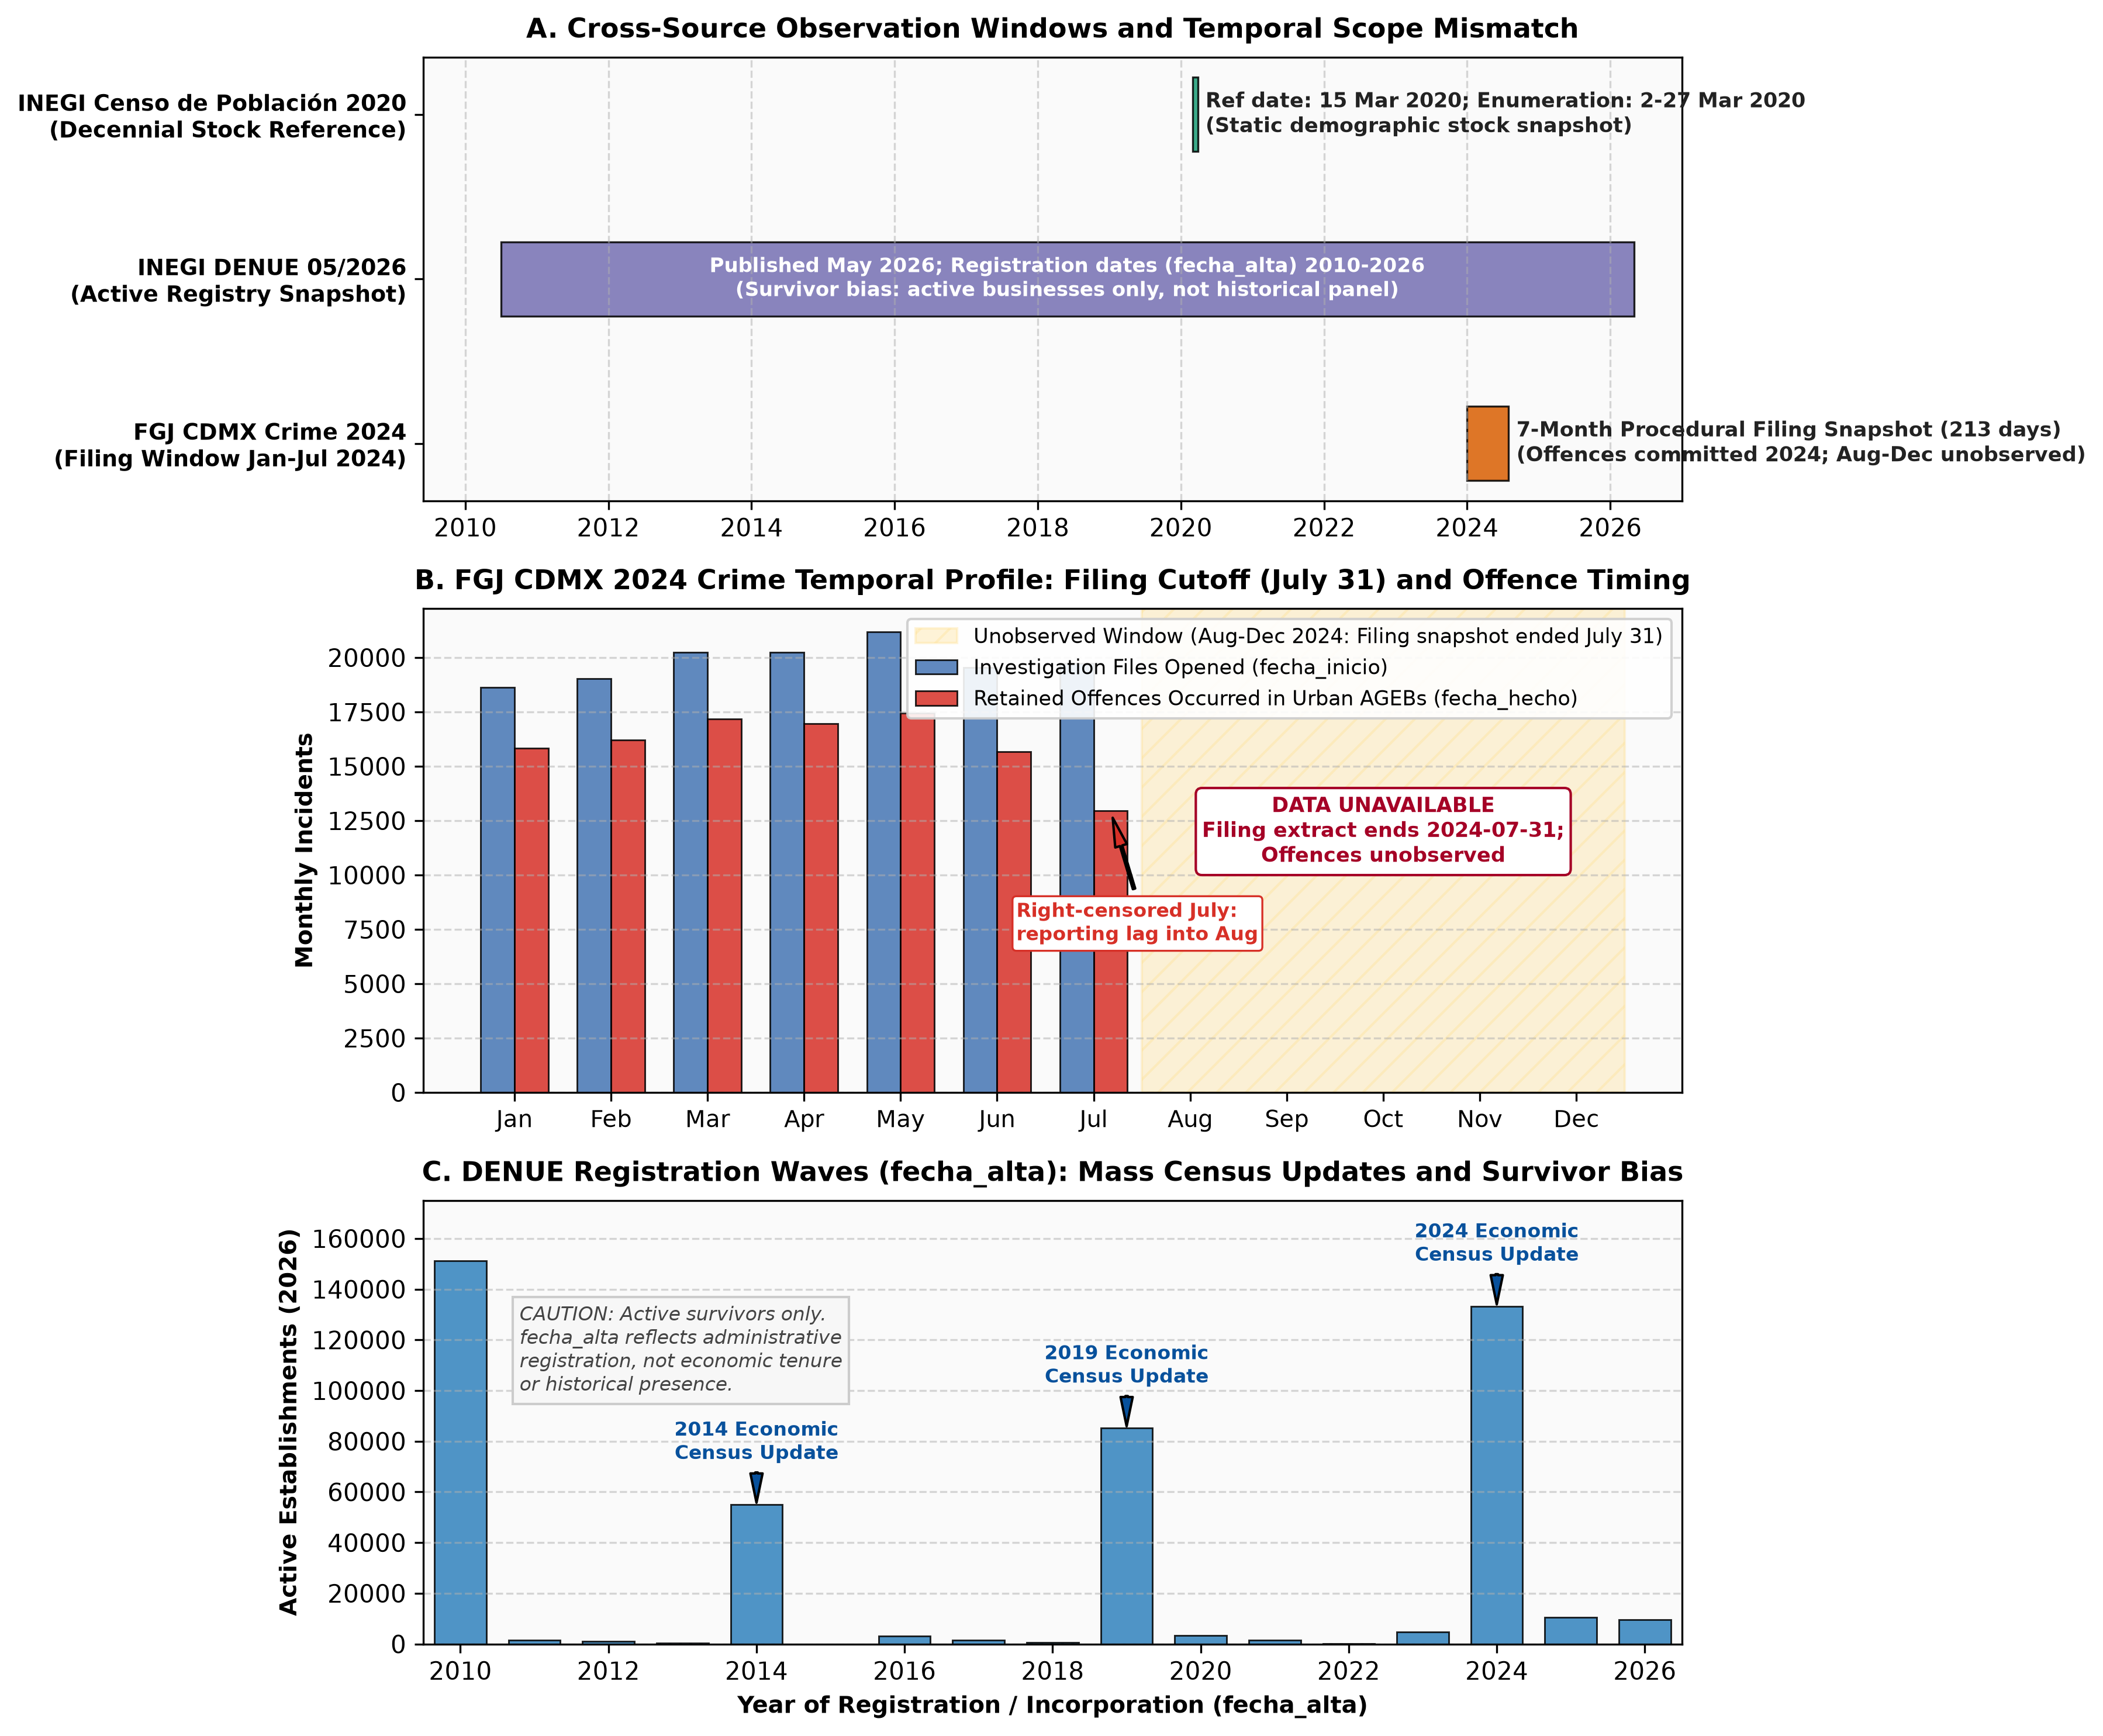

In [4]:
# Profile crime filing and offence dates
crime_info = crime_temporal_and_grain_check()

print("=== FGJ CDMX 2024 Crime Temporal Profile ===")
print(f"Procedural filing window (fecha_inicio):  {crime_info['filing_start']} to {crime_info['filing_end']}")
print(f"Observed calendar days:                   {crime_info['calendar_days_count']} days (including {crime_info['february_days_count']} days in Feb 2024)")
print(f"Observed filing months:                   {crime_info['filing_months_count']} months (Jan - Jul 2024; Aug-Dec unobserved)")
print(f"Total raw investigation files:            {crime_info['raw_count']:,}")
print(f"Offences occurring in year {CRIME_YEAR}:         {crime_info['year_2024_count']:,}")
print(f"Eligible criminal offences:               {crime_info['eligible_count']:,}")
print(f"Valid geocoded coordinates:               {crime_info['valid_coords_count']:,}")
print(f"Retained incidents in urban AGEBs:        {crime_info['retained_count']:,}")
print(f"Incidents outside urban AGEBs:            {crime_info['outside_count']:,}")
print(f"Unparseable / missing offence dates:      {crime_info['invalid_dates_count']:,}")
print(f"Offences occurring in prior years (<2024): {crime_info['earlier_years_count']:,}")
print(f"Verified input SHA-256 digest:            {crime_info['sha256_digest']}")

print(f"Unparseable / missing filing dates:       {crime_info['invalid_filing_dates_count']:,}")
denue_alta = parse_alta_date(read_denue()["fecha_alta"])
print(f"Unavailable DENUE registration months:   {denue_alta.isna().sum():,}")

# Generate and export the 3-panel temporal coverage figure (reusing precomputed monthly series)
fig, axes = plot_cross_source_temporal_coverage(
    denue_alta_series=denue_alta,
    filing_monthly=crime_info["monthly_filings"],
    offence_monthly=crime_info["monthly_retained_offences"],
)
plt.close(fig)  # Close memory handle after saving

temporal_fig_rel = (OUTPUT_FIGURES / "14_temporal_coverage.png").relative_to(ROOT) if (OUTPUT_FIGURES / "14_temporal_coverage.png").is_relative_to(ROOT) else "outputs/figures/14_temporal_coverage.png"
print(f"\nSaved temporal coverage figure to: {temporal_fig_rel}")
display(Image(filename=str(OUTPUT_FIGURES / "14_temporal_coverage.png")))


### Interpretation of Temporal Figure Findings

1. **Panel A (Observation Windows):** Illustrates the asynchronous structure across sources: the 2020 demographic baseline (March 2020), the cumulative 2010–2026 economic directory (active survivors), and the 7-month 2024 crime snapshot. Cross-sectional KPI rates (e.g., crime rate per 1,000 residents or business density) must be interpreted as spatial co-locations across contemporaneously available snapshots, not synchronized real-time interactions.
2. **Panel B (Filing Cutoff & Right-Censoring):** Procedural filing dates (`fecha_inicio`) end abruptly on **2024-07-31**. Incident counts by offence date (`fecha_hecho`) remain steady from January through June (~15.8k–17.4k per month) but drop to 12,963 in July. Part of this decline reflects **right-censoring** (offences committed in late July whose investigation files were opened in August or later are excluded from this release snapshot); however, the extract cutoff alone does not establish what proportion of the July decline is attributable to censoring versus underlying reporting variation. August–December months are unobserved (`NaN`), not periods of zero crime.
3. **Panel C (DENUE Registration Waves):** Distinct registration spikes in 2014 (54,995), 2019 (85,152), and 2024 (133,241) align with national Economic Census update cycles. Because inactive businesses are dropped from DENUE, this distribution reflects administrative registration waves and survivorship, not continuous business longevity.


## 4. Source-to-Urban-AGEB Summary Table

The table below reconciles each source dataset from its raw incoming records through filtering and spatial assignment into the final Mexico City urban AGEB data warehouse dimensions and fact tables.


In [5]:
# Generate source integration summary table
summary_table = build_source_integration_summary_table(
    census_results=census_comp,
    denue_results=denue_comp,
    crime_results=crime_info,
)

# Export to figures directory
csv_path = OUTPUT_FIGURES / "14_source_integration_summary.csv"
summary_table.to_csv(csv_path, index=False)
csv_rel = csv_path.relative_to(ROOT) if csv_path.is_relative_to(ROOT) else "outputs/figures/14_source_integration_summary.csv"
print(f"Exported summary table to: {csv_rel}")

display(summary_table)

# Assert core integration invariants
assert summary_table.loc[0, "Retained in Urban AGEBs"] == 2_431
assert summary_table.loc[1, "Retained in Urban AGEBs"] == 2_431
assert summary_table.loc[2, "Retained in Urban AGEBs"] == 461_231
assert summary_table.loc[3, "Retained in Urban AGEBs"] == 112_285
print("\n[OK] All summary table entities reconcile with TEAM_PLAN §3.5 ground truth.")


Exported summary table to: outputs\figures\14_source_integration_summary.csv


,Source Layer,Publisher,Original Grain,Raw Records,Filtered / Eligible,Retained in Urban AGEBs,Retention % (Raw),Retention % (Eligible),Retained Measure,Integration Status
0,Marco Geoestadístico 2020 (09a.shp),INEGI,One polygon per geostatistical unit,2431,2431,2431,100.00,100.00,"2,431 polygons (792.15 km²)","Complete reference boundary frame (2,348 city ..."
1,Censo de Población y Vivienda 2020,INEGI,"Tabular records (blocks, AGEBs, localities, mu...",68941,2433,2431,3.53,99.92,"9,138,524 residents","Filtered 68,941 mixed-grain rows to 2,433 AGEB..."
2,DENUE 05/2026,INEGI,One economic establishment point (lat/lon),462732,462729,461231,99.68,99.68,"461,231 establishments",99.84% reported-AGEB agreement; drops 3 invali...
3,Carpetas de Investigación 2024,FGJ CDMX,"One investigation file (carpeta) with date, ca...",138630,119666,112285,81.00,93.83,"112,285 investigation files",7-month filing extract (Jan-Jul); retains 93.8...



[OK] All summary table entities reconcile with TEAM_PLAN §3.5 ground truth.


## 5. Analytical Synthesis and Limitations

### Key Integration Insights
- **Unified Spatial Unit:** The 2,431 urban AGEB polygons of Mexico City (792.15 km² total area; 2,348 city core and 83 outlying urban pueblos) form an empirically sound, topologically clean reference framework.
- **High Data Retention:** Attrition across datasets is minimal and fully documented:
  - Demographic coverage: 99.92% of urban census population retained (9,138,524 residents); 2 non-polygon AGEBs (7,108 residents) safely excluded.
  - Economic coverage: 99.68% of raw DENUE establishments retained (461,231 establishments) with 99.84% boundary concordance.
  - Crime coverage: 93.83% of eligible 2024 crimes (112,285 incidents) successfully geolocated and mapped inside urban AGEBs.

### Interpretation Cautions (Non-Causal Posture)
- **Temporal Asynchrony:** Demographics reflect 2020, economic establishments reflect a 2026 active registry, and public safety files reflect a 7-month snapshot of 2024. Spatial correlations between these layers indicate cross-sectional spatial co-location, not direct causation or dynamic reaction.
- **Reporting Bias in Public Safety:** Investigation files (`carpetas de investigación`) capture reported and formally opened offences, which are subject to substantial dark figure (*cifra negra*) variations across socioeconomic strata and alcaldías.
- **Denominator Sensitivities:** Per-capita crime rates in commercial or transit hub AGEBs with tiny resident populations ($<100$ residents) can become extreme outliers. Downstream spatial analyses (Moran's I, LISA, and regression models) must apply `exclude_low_population=True` to maintain robustness.
